# **IMPLEMENTANDO A REDE CONSTRUÍDA PARA CLASSIFICAÇÃO MULTICLASSE UTILIZANDO FRAMEWORKS**

A partir de agora, aumentarei o nível de abstração, pois começarei a utilizar o TensorFlow e o Keras para não ter que implementar todas as novas técnicas do zero e poder aprimorar as demonstrações feitas aqui.

## Importando o que será necessário para nossa aplicação

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
import numpy as np
import logging

tf.get_logger().setLevel(logging.ERROR)
tf.random.set_seed(42)

EPOCHS = 20
BATCH_SIZE = 1

## Carregando e preparando o dataset *MNIST*

Como o *MNIST* já é um dataset muito comum e famoso ele já está incluído no *Keras*.

In [7]:
#Carregando o dataset MNIST
mnist = keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

#Normalizando os dados
mean = np.mean(train_images)
stddev = np.std(train_images)
train_images = (train_images - mean) / stddev
test_images = (test_images - mean) / stddev

#Realizando o encode dos rótulos
train_labels = to_categorical(train_labels, num_classes=10)
test_labels = to_categorical(test_labels, num_classes=10)

Uma nota sobre como esses *frameworks* nos ajudam na hora da prática. Para realizar a codificação *one-hot*, usei a função *to_categorical*, em vez de fazê-la manualmente como fiz no código da classificação multiclasse.

## Criando a rede

In [12]:
#Objeto usado para inicializar os pesos da rede
initializer = keras.initializers.RandomUniform(minval=-0.1, maxval=0.1)


#Criando o modelo sequencial com 784 inputs (todos os pixels da imagem 28x28)
#Duas camadas densas (totalmente conectadas), assim como no exemplo anterior com 25 e 10 neurônios, respectivamente
#A função de ativação da camada oculta é a tanh
#A função de ativação da camada de saída é a sigmoid
model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(25, activation='tanh', kernel_initializer=initializer, bias_initializer='zeros'),
    keras.layers.Dense(10, activation='sigmoid', kernel_initializer=initializer, bias_initializer='zeros')
])

Instanciamos a rede usando um objeto *keras.Sequential*, o que significa que estamos usando uma API do Keras.

Com relação as camadas, a primeira é uma camada *Flatten*, ou seja, ela não faz cálculos, apenas reorganiza a estrutura da entrada de um *array* de 28x28 para um de 784 elementos.

A segunda e a terceira camada são do tipo *Dense*, o que significa que são *fully connected* (totalmente conectadas). Após isso indico como argumento a quantidade de neurônios, a função de ativação, o inicializador de pesos e os pesos de *bias* são inicializados como 0.

Nota-se que não especifiquei a quantidade de entradas para a segunda e terceira camadas. Esse número de entradas é definido quando instancio que elas são totalmente conectadas e quantos neurônios cada uma possui. Isso destaca, mais uma vez, o alto nível de abstração que estamos trabalhando, disponibilizado pelo uso dos *frameworks*.

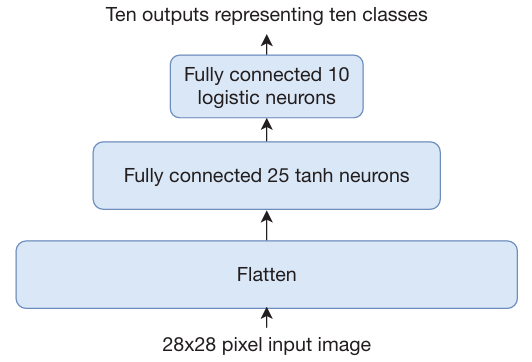 *Ilustração dessa rede no nível de abstração comentado acima.*

## Treinamento da rede

In [9]:
#O otimizador usado é o SGD (Stochastic Gradient Descent) com uma taxa de aprendizado de 0.01
opt = keras.optimizers.SGD(learning_rate=0.01)

#Compilando o modelo com a função de perda 'mean_squared_error' e a métrica 'accuracy'
model.compile(loss='mean_squared_error', optimizer=opt, metrics=['accuracy'])

#Treinando o modelo com 20 epocas.
#Shuffle=True significa que os dados serão embaralhados a cada época
#Os pesos serão atualizados depois de cada exemplo, já que o batch size é 1
history = model.fit(train_images, train_labels, validation_data=(test_images, test_labels), 
                    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2, shuffle=True)

Epoch 1/20
60000/60000 - 149s - 2ms/step - accuracy: 0.6704 - loss: 0.0528 - val_accuracy: 0.8758 - val_loss: 0.0275
Epoch 2/20
60000/60000 - 97s - 2ms/step - accuracy: 0.8924 - loss: 0.0219 - val_accuracy: 0.9093 - val_loss: 0.0177
Epoch 3/20
60000/60000 - 90s - 2ms/step - accuracy: 0.9115 - loss: 0.0166 - val_accuracy: 0.9176 - val_loss: 0.0152
Epoch 4/20
60000/60000 - 135s - 2ms/step - accuracy: 0.9193 - loss: 0.0146 - val_accuracy: 0.9218 - val_loss: 0.0139
Epoch 5/20
60000/60000 - 174s - 3ms/step - accuracy: 0.9247 - loss: 0.0135 - val_accuracy: 0.9252 - val_loss: 0.0131
Epoch 6/20
60000/60000 - 153s - 3ms/step - accuracy: 0.9288 - loss: 0.0127 - val_accuracy: 0.9284 - val_loss: 0.0125
Epoch 7/20
60000/60000 - 2584s - 43ms/step - accuracy: 0.9321 - loss: 0.0121 - val_accuracy: 0.9312 - val_loss: 0.0121
Epoch 8/20
60000/60000 - 149s - 2ms/step - accuracy: 0.9345 - loss: 0.0116 - val_accuracy: 0.9330 - val_loss: 0.0118
Epoch 9/20
60000/60000 - 84s - 1ms/step - accuracy: 0.9371 - los

Sobre o **gradiente descendente estocástico (SGD)**, ele executa uma época de treinamento para cada exemplo dentro do conjunto de dados e atualiza os parâmetros de cada exemplo de treinamento, um de cada vez.

Um ponto importante a se notar é que foi muito simples essa implementação comparada a outra implementação que fiz sem utilizar nenhum *framework*. O *framework* permite a utilização de técnicas avançadas, mantendo o tamanho do código em um nível controlado.

------------------------------------------------
-----------------------------------------------

**NEURÔNIOS SATURADOS**

Leve pausa para comentar sobre esse importante tópico: os **neurônios saturados.**

Como podemos ver pela imagem abaixo, ambas as funções que usei como funções de ativação dos neurônios, fora desse intervalo mostrado na imagem, elas são "desinteressantes". Isso ocorre pois, fora desse intervalo, elas funcionam quase como funções constantes, sendo apenas linhas horizontais.

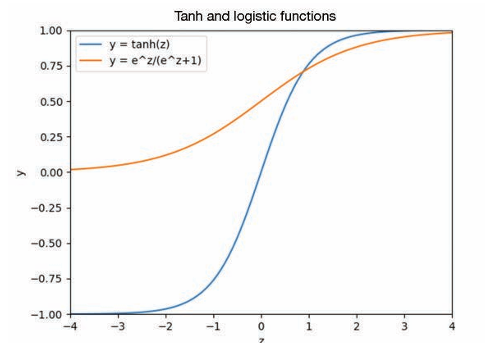 *Gráfico das duas funções de ativação usadas*

O nosso algoritmo de aprendizado funciona calculando a derivada da função de erro e, a partir disso, determinando quais pesos ajustar. Nesse sentido, se o valor de *z*, ou seja, da soma ponderada, estiver dentro do intervalo mostrado na imagem acima, nós conseguiremos mudar a saída da função. No entanto, considerando o valor de *z* como um número grande (positivo ou negativo), ao alterar o *input* em uma pequena, ou em grande, quantidade, isso não afetará na saída da função, pois ela pe uma linha horizontal nessas regiões.  

A partir dessa mudança no valor de entrada e pouca/nenhuma mudança na saída, falamos que o **neurônio está saturado.**

Neurônios saturados podem fazer o aprendizado parar completamente. Isso ocorre pois quando vamos calcular o gradiente, ou seja, derivada, dessas funções de ativação para valores grandes de *z*, a derivada é **0**, o que interfere no nosso algoritmo de aprendizado.

**FORMAS DE EVITAR NEURÔNIOS SATURADOS**

1. **Inicialização de pesos**: inicializar os pesos com valores menores para que a soma ponderada não fique muito grande, mantendo o *input* da função de ativação próximo de 0. (*Ex: inicialização de **Glorot** e inicialização de **He**)*;
2. **Padronização das entradas**: padronizar os dados de entrada, deixando-os centrados em 0 reduz o risco de saturar os neurônios desde o início;
3. **Normalização em lote**: já que normalizar as entradas não previne necessariamente a saturação dos neurônios nas camadas ocultas, a ideia agora é normalizar os valores também dentro da rede, evitando assim que os neurônios ocultos se saturem.
